In [23]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [24]:
# Create synthetic dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (800, 10)
Testing Shape : (200, 10)


In [25]:
# High Bias Example(Underfitting)
high_bias_model = LogisticRegression(max_iter=1000)

high_bias_model.fit(X_train, y_train)

train_pred_bias = high_bias_model.predict(X_train)
test_pred_bias  = high_bias_model.predict(X_test)

train_acc_bias = accuracy_score(y_train, train_pred_bias)
test_acc_bias  = accuracy_score(y_test, test_pred_bias)

print("=== High Bias Model ===")
print(f"Train Accuracy: {train_acc_bias:.3f}")
print(f"Test Accuracy : {test_acc_bias:.3f}")
print(f"Gap           : {abs(train_acc_bias - test_acc_bias):.3f}")

=== High Bias Model ===
Train Accuracy: 0.849
Test Accuracy : 0.800
Gap           : 0.049


In [26]:
# High Variance Example(Overfitting)
high_variance_model = DecisionTreeClassifier(
    random_state=42
)

high_variance_model.fit(X_train, y_train)

train_pred_var = high_variance_model.predict(X_train)
test_pred_var  = high_variance_model.predict(X_test)

train_acc_var = accuracy_score(y_train, train_pred_var)
test_acc_var  = accuracy_score(y_test, test_pred_var)

print("=== High Variance Model ===")
print(f"Train Accuracy: {train_acc_var:.3f}")
print(f"Test Accuracy : {test_acc_var:.3f}")
print(f"Gap           : {abs(train_acc_var - test_acc_var):.3f}")

=== High Variance Model ===
Train Accuracy: 1.000
Test Accuracy : 0.820
Gap           : 0.180


In [27]:
# Balanced Model Example
balanced_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

balanced_model.fit(X_train, y_train)

train_pred_bal = balanced_model.predict(X_train)
test_pred_bal  = balanced_model.predict(X_test)

train_acc_bal = accuracy_score(y_train, train_pred_bal)
test_acc_bal  = accuracy_score(y_test, test_pred_bal)

print("=== Balanced Model ===")
print(f"Train Accuracy: {train_acc_bal:.3f}")
print(f"Test Accuracy : {test_acc_bal:.3f}")
print(f"Gap           : {abs(train_acc_bal - test_acc_bal):.3f}")

=== Balanced Model ===
Train Accuracy: 0.919
Test Accuracy : 0.810
Gap           : 0.109


In [28]:
# Diagnostic Table
results = pd.DataFrame({
    "Model": [
        "High Bias",
        "High Variance",
        "Balanced"
    ],
    "Train Accuracy": [
        train_acc_bias,
        train_acc_var,
        train_acc_bal
    ],
    "Test Accuracy": [
        test_acc_bias,
        test_acc_var,
        test_acc_bal
    ]
})

results["Gap"] = abs(
    results["Train Accuracy"] - results["Test Accuracy"]
)

results

,Model,Train Accuracy,Test Accuracy,Gap
0,High Bias,0.84875,0.80,0.04875
1,High Variance,1.00000,0.82,0.18000
2,Balanced,0.91875,0.81,0.10875


In [29]:
#Cross-validation Analysis
cv_scores = cross_val_score(
    balanced_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print(f"\nMean CV Accuracy: {cv_scores.mean():.3f}")
print(f"Std Dev          : {cv_scores.std():.3f}")

Cross Validation Scores:
[0.80625 0.83125 0.875   0.86875 0.85   ]

Mean CV Accuracy: 0.846
Std Dev          : 0.025


In [30]:
# Learning Curve 
train_sizes, train_scores, val_scores = learning_curve(
    balanced_model,
    X_train,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

In [31]:
# Compute mean scores
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

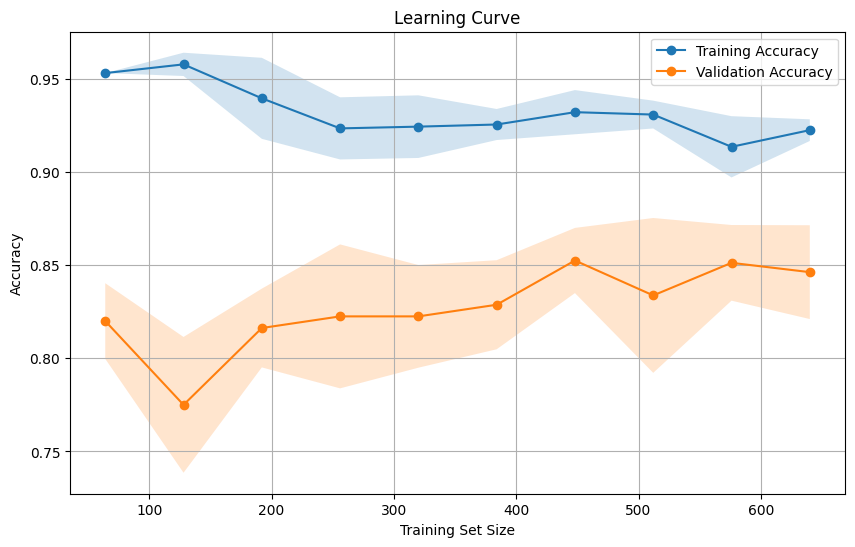

In [32]:
# Plot Learning Curve
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
#KNN Bias Variance Example

#Small K (High Variance)
knn_small = KNeighborsClassifier(n_neighbors=1)

knn_small.fit(X_train, y_train)

train_small = knn_small.score(X_train, y_train)
test_small  = knn_small.score(X_test, y_test)

print("=== KNN Small K ===")
print(f"Train Accuracy: {train_small:.3f}")
print(f"Test Accuracy : {test_small:.3f}")

#Large K (High Bias)
knn_large = KNeighborsClassifier(n_neighbors=50)

knn_large.fit(X_train, y_train)

train_large = knn_large.score(X_train, y_train)
test_large  = knn_large.score(X_test, y_test)

print("=== KNN Large K ===")
print(f"Train Accuracy: {train_large:.3f}")
print(f"Test Accuracy : {test_large:.3f}")

=== KNN Small K ===
Train Accuracy: 1.000
Test Accuracy : 0.920
=== KNN Large K ===
Train Accuracy: 0.906
Test Accuracy : 0.830


# Understanding the Results
## High Bias
- Low training accuracy
- Low testing accuracy
- Small train-test gap
- Model underfits
## High Variance
- Very high training accuracy
- Lower testing accuracy
- Large train-test gap
- Model overfits
## Balanced Model
- Good train accuracy
- Good test accuracy
- Small acceptable gap
- Better generalization
-------------------------

# Practical Fixes
## Reduce High Bias
- Increase model complexity
- Add better features
- Reduce regularization
- Use more flexible models
## Reduce High Variance
- Add more training data
- Use regularization
- Reduce model complexity
- Use feature selection
- Apply cross-validation
--------------------------

# Final Takeaways
## Bias
- Model is too simple
- Cannot capture patterns
- Causes underfitting
## Variance
- Model memorizes noise
- Performs poorly on unseen data
- Causes overfitting
## Goal

#### Find the balance where:
- Train accuracy is good
- Test accuracy is good
- Gap is small
- Model generalizes well